# 🎓 Análisis Exploratorio — Top 100 Universidades del Mundo

---

**¿Qué es este notebook?**  
Un notebook de Jupyter mezcla tres cosas en un mismo documento:
- 📝 **Texto explicativo** (como este bloque) — para explicar qué hacemos y por qué
- 💻 **Código Python** — las instrucciones que la computadora ejecuta
- 📊 **Gráficos** — los resultados visuales del análisis

Podés ejecutar cada bloque de código haciendo clic en él y presionando `Shift + Enter`.

---

**Herramientas que usamos:**

| Librería | Para qué sirve |
|---|---|
| `pandas` | Cargar y manipular tablas de datos (como Excel) |
| `matplotlib` | Crear gráficos |
| `seaborn` | Gráficos estadísticos más elaborados (heatmap) |
| `numpy` | Cálculos matemáticos |

---

**Preguntas que vamos a responder:**
1. ¿El ratio estudiante/profesor se correlaciona con el ranking?
2. ¿Las que ofrecen más programas están mejor rankeadas?
3. ¿Públicas o privadas tienen más recursos?
4. ¿Existe un "perfil típico" de las Top 10?


---
## Paso 1 — Importar librerías

Antes de usar cualquier herramienta hay que "importarla".  
Es como abrir un programa antes de usarlo.  
El `as` nos permite darle un nombre más corto (`pd` en lugar de `pandas`).


In [ ]:
import matplotlib
matplotlib.use('Agg')              # guarda gráficos en archivo (no los muestra en ventana)

import matplotlib.pyplot as plt        # módulo principal para dibujar gráficos
import matplotlib.patches as mpatches  # para crear ítems de leyenda personalizados
import seaborn as sns                  # librería para gráficos estadísticos
import pandas as pd                    # para trabajar con tablas de datos
import numpy as np                     # para operaciones matemáticas
import warnings
warnings.filterwarnings('ignore')      # ocultamos advertencias menores

print("✅ Librerías importadas correctamente")

---
## Paso 2 — Configurar colores y estilo visual

Definimos los colores **una sola vez** para que todos los gráficos sean consistentes.  
Si queremos cambiar un color, lo cambiamos acá y se actualiza en todos lados automáticamente.

Los colores están en formato **HEX** (`#RRGGBB`), el mismo que usa el diseño web.


In [ ]:
# Paleta de colores del análisis
DARK_BG  = '#0d1117'   # fondo general (gris muy oscuro)
SURFACE  = '#161b22'   # fondo de los gráficos
SURFACE2 = '#1c2333'   # fondo de cajas de texto
BORDER   = '#30363d'   # líneas y bordes
TEXT     = '#e6edf3'   # texto principal (blanco suave)
MUTED    = '#8b949e'   # texto secundario (gris)
ACCENT   = '#58a6ff'   # azul   → Top 10 / dato principal
ACCENT2  = '#f0a838'   # dorado → privadas / dato secundario
ACCENT3  = '#3fb950'   # verde  → promedios y tendencias
ACCENT4  = '#f85149'   # rojo   → outliers y valores altos

# plt.rcParams establece el "tema" global de todos los gráficos
# Es como configurar el estilo antes de empezar a dibujar
plt.rcParams.update({
    'figure.facecolor': DARK_BG,    # fondo de toda la figura
    'axes.facecolor':   SURFACE,    # fondo dentro del área del gráfico
    'axes.edgecolor':   BORDER,
    'axes.labelcolor':  MUTED,
    'axes.titlecolor':  TEXT,
    'axes.titlesize':   12,
    'axes.grid':        True,
    'grid.color':       BORDER,
    'grid.linewidth':   0.6,
    'xtick.color':      MUTED,
    'ytick.color':      MUTED,
    'text.color':       TEXT,
    'font.family':      'monospace',
    'legend.facecolor': SURFACE2,
    'legend.edgecolor': BORDER,
    'legend.fontsize':  8,
})

nota_style = dict(boxstyle='round,pad=0.4', facecolor=SURFACE2, edgecolor=BORDER)

print("✅ Estilo visual configurado")

---
## Paso 3 — Cargar los datos

`pd.read_csv()` lee el archivo CSV y lo convierte en un **DataFrame**.  
Un DataFrame es una tabla con filas y columnas, similar a una hoja de Excel pero dentro de Python.

Lo primero que hacemos es explorar la estructura: cuántas filas hay, qué columnas existen y si faltan datos.


In [ ]:
# Cargamos el archivo CSV como DataFrame (tabla de datos)
df = pd.read_csv('top_100_universities_dataset.csv')

# .shape nos dice (filas, columnas)
print(f"📦 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

# .isnull().sum().sum() cuenta todas las celdas vacías del dataset
print(f"🔍 Valores nulos: {df.isnull().sum().sum()} — dataset limpio ✓")

# Mostramos las primeras 5 filas para ver cómo están los datos
# .head() devuelve las primeras N filas (5 por defecto)
print("\n📋 Primeras 5 filas:")
df.head()

---
## Paso 4 — Preparar los datos

Rara vez los datos vienen exactamente como los necesitamos.  
Acá creamos una nueva variable calculada y separamos el dataset en grupos.

**Nueva variable: `ratio`**  
Cuántos alumnos tiene que atender cada profesor.  
Fórmula: `Total_Students / Total_Faculty`

En pandas, dividir dos columnas opera **fila por fila automáticamente** — no necesitamos un bucle.


In [ ]:
# Creamos la columna 'ratio': alumnos por cada profesor
# pandas divide fila por fila de forma automática
df['ratio'] = (df['Total_Students'] / df['Total_Faculty']).round(2)

# Separamos en dos grupos para comparar:
#   top10 → posiciones 1 a 10
#   rest  → posiciones 11 a 100
# df[condición] filtra solo las filas que cumplen esa condición
# .copy() crea una copia independiente del DataFrame original
top10 = df[df['Position'] <= 10].copy()
rest  = df[df['Position'] > 10].copy()

# Nombres cortos para los ejes de los gráficos
nombres = ['Oxford','Columbia','Michigan','Edinburgh','Cambridge',
           'Michigan*','UCL','Imperial','Princeton','Caltech']

print(f"✅ Nueva columna 'ratio' creada")
print(f"   Mínimo: {df['ratio'].min()} | Máximo: {df['ratio'].max()} | Promedio: {df['ratio'].mean():.1f}")
print(f"\n   Grupo top10 → {len(top10)} universidades")
print(f"   Grupo rest   → {len(rest)} universidades")

# Vista de las Top 10 con las variables clave
top10[['Position','University_Name','Total_Faculty','Programs_Offered','ratio','University_Type']]

---
## Paso 5 — Analizar correlaciones

La **correlación** mide cuánto se relacionan dos variables numéricas.

| Valor | Significado |
|---|---|
| Cerca de **+1** | Relación directa: cuando una sube, la otra también |
| Cerca de **−1** | Relación inversa: cuando una sube, la otra baja |
| Cerca de **0** | Sin relación: son independientes |

`.corr()` calcula la correlación entre todas las columnas numéricas automáticamente.  
Al agregar `['Position']` al final, extraemos solo la correlación de cada variable **con el ranking**.


In [ ]:
# .corr() genera una matriz de correlaciones entre todas las columnas numéricas
# Al seleccionar ['Position'] al final, vemos solo la correlación con el ranking
corr = df[['Position','Total_Faculty','Programs_Offered',
           'ratio','Campus_Area_Acres']].corr()['Position'].round(3)

print("Correlación de cada variable con la Posición en el ranking:\n")
for var, val in corr.items():
    if var == 'Position':
        continue  # la correlación de Position consigo misma siempre es 1, la saltamos
    nivel = "🔴 Sin relación" if abs(val) < 0.1 else \
            "🟡 Débil"        if abs(val) < 0.3 else \
            "🟢 Moderada"
    print(f"  {var:<25} {val:>7}   {nivel}")

print("\n💡 Conclusión: ninguna variable tiene correlación fuerte con el ranking.")

---
## Paso 6 — Comparar Top 10 vs. el resto

Comparamos los **promedios** de las Top 10 contra las posiciones 11–100.  
`.mean()` calcula el promedio de una columna numérica.

Esto nos permite ver si las mejores universidades tienen más o menos recursos que el promedio del ranking.


In [ ]:
print("Comparación de promedios — Top 10 vs. Resto del ranking\n")
print(f"{'Métrica':<25} {'Top 10':>10} {'Resto':>10} {'Diferencia':>12}")
print("-" * 60)

for m in ['Total_Faculty', 'Programs_Offered', 'ratio']:
    t    = top10[m].mean()         # promedio de las Top 10
    r    = rest[m].mean()          # promedio del resto
    diff = (t - r) / r * 100       # diferencia porcentual
    tag  = "↑ más" if diff > 0 else "↓ menos"
    print(f"  {m:<23} {t:>10.1f} {r:>10.1f}   {abs(diff):>5.1f}% {tag}")

print("\n💡 Dato sorprendente: las Top 10 tienen MENOS facultad y programas que el resto.")

---
## 📊 Gráfico 1 — Ratio Estudiantes / Profesor

**¿Qué es un gráfico de barras?**  
Compara una misma métrica entre varias categorías.  
Acá vemos el ratio de cada una de las 10 universidades.

**Cómo leer este gráfico:**
- Cada barra = una universidad del Top 10
- La altura de la barra = cuántos alumnos atiende cada profesor
- La línea punteada verde = promedio del grupo
- Colores: 🔵 ratio bajo (< 10) · 🟡 medio (10–25) · 🔴 alto (> 25)

**`ax.bar()`** dibuja las barras.  
**`ax.axhline()`** dibuja la línea horizontal del promedio.  
**`mpatches.Patch()`** crea los elementos de la leyenda manualmente.


In [ ]:
fig1, ax1 = plt.subplots(figsize=(11, 4.5), facecolor=DARK_BG)

ratios = top10['ratio'].values   # .values convierte la columna a un array de números

# Asignamos un color a cada barra según el valor del ratio
# Esta es una "list comprehension": genera una lista con una condición por elemento
bcolors = [ACCENT if r < 10 else ACCENT2 if r < 25 else ACCENT4 for r in ratios]

# ax.bar() dibuja el gráfico de barras
# range(10) → posiciones X: 0,1,...,9 | ratios → alturas de las barras
bars = ax1.bar(range(10), ratios, color=bcolors, width=0.6, edgecolor=DARK_BG, linewidth=0.6)

# Agregamos el número exacto encima de cada barra
# zip(bars, ratios) combina cada barra con su valor
for bar, val in zip(bars, ratios):
    ax1.text(bar.get_x() + bar.get_width() / 2,  # centro de la barra en X
             bar.get_height() + 0.5,              # un poco por encima de la barra
             f'{val}', ha='center', va='bottom', fontsize=8, color=TEXT, fontweight='bold')

# axhline dibuja una línea horizontal en el promedio del grupo
mean_r = ratios.mean()
ax1.axhline(mean_r, color=ACCENT3, lw=1.2, linestyle='--', alpha=0.8)
ax1.text(9.45, mean_r + 0.8, f'prom {mean_r:.1f}', ha='right', fontsize=7.5, color=ACCENT3)

ax1.set_xticks(range(10))
ax1.set_xticklabels(nombres, rotation=35, ha='right', fontsize=8.5)
ax1.set_title('Ratio Estudiantes / Profesor — Top 10 Universidades', color=TEXT)
ax1.set_ylabel('Alumnos por profesor', color=MUTED)

# Creamos la leyenda manualmente porque los colores se asignan barra por barra
leg1 = [mpatches.Patch(color=ACCENT, label='Bajo < 10'),
        mpatches.Patch(color=ACCENT2, label='Medio 10–25'),
        mpatches.Patch(color=ACCENT4, label='Alto > 25')]
ax1.legend(handles=leg1, loc='upper left')
ax1.text(0.5, -0.22,
         'Correlación ratio ↔ ranking = 0.001 → Sin relación estadística. El ratio no determina quién está en el top.',
         transform=ax1.transAxes, ha='center', fontsize=8, color=MUTED, style='italic', bbox=nota_style)

plt.tight_layout(pad=1.5)
plt.show()

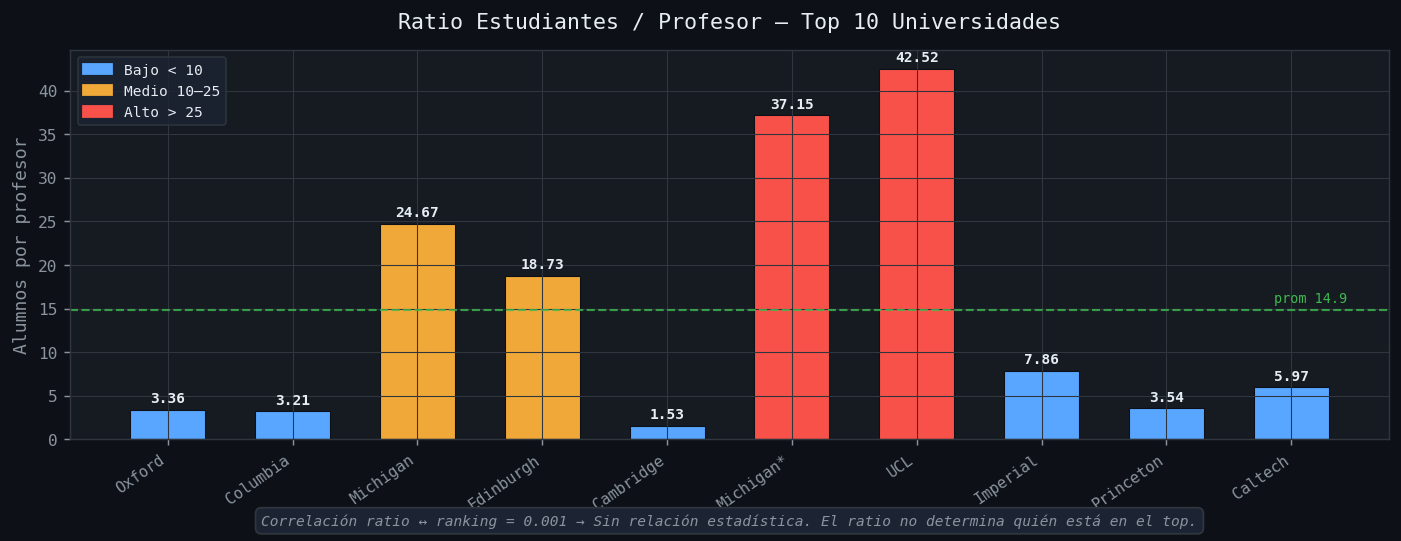

In [ ]:
# (gráfico generado por el bloque de código anterior)

---
## 📊 Gráfico 2 — Programas Ofrecidos vs. Posición

**¿Qué es un scatter plot (diagrama de dispersión)?**  
Muestra la relación entre **dos variables numéricas**.  
Cada punto es una universidad. Si los puntos forman una línea → hay correlación.  
Si están dispersos (como acá) → no hay relación.

**Cómo leer este gráfico:**
- Eje X = posición en el ranking (1 = mejor)
- Eje Y = cantidad de programas que ofrece la universidad
- 🔴 puntos grandes = Top 10 · 🔵 puntos pequeños = posiciones 11–40
- La línea punteada = tendencia general (casi plana = sin relación)

**`np.polyfit()`** calcula la línea de tendencia usando regresión lineal.


In [ ]:
fig2, ax2 = plt.subplots(figsize=(11, 4.5), facecolor=DARK_BG)

top40 = df[df['Position'] <= 40]  # filtramos las primeras 40 posiciones

# Colores y tamaños distintos para diferenciar Top 10 del resto
c2 = [ACCENT4 if p <= 10 else ACCENT + 'bb' for p in top40['Position']]
s2 = [100     if p <= 10 else 40             for p in top40['Position']]

ax2.scatter(top40['Position'], top40['Programs_Offered'],
            c=c2, s=s2, alpha=0.85, edgecolors=DARK_BG, linewidths=0.4)

# Línea de tendencia con regresión lineal:
# np.polyfit(x, y, 1) calcula pendiente e intercepto de la recta
# np.poly1d() convierte esos coeficientes en una función evaluable
# np.linspace(1, 40, 100) genera 100 puntos equidistantes entre 1 y 40
z2  = np.polyfit(df['Position'], df['Programs_Offered'], 1)
xl2 = np.linspace(1, 40, 100)
ax2.plot(xl2, np.poly1d(z2)(xl2), color=MUTED, lw=1, linestyle='--', alpha=0.6)

ax2.set_title('Programas Ofrecidos vs. Posición en el Ranking (Top 40)', color=TEXT)
ax2.set_xlabel('Posición en el ranking', color=MUTED)
ax2.set_ylabel('Programas ofrecidos', color=MUTED)

leg2 = [mpatches.Patch(color=ACCENT4, label='Top 10'),
        mpatches.Patch(color=ACCENT,  label='Pos. 11–40')]
ax2.legend(handles=leg2)
ax2.text(0.5, -0.22,
         'Top 10 promedia 217 programas vs. 247 del resto. Más programas NO implica mejor posición.',
         transform=ax2.transAxes, ha='center', fontsize=8, color=MUTED, style='italic', bbox=nota_style)

plt.tight_layout(pad=1.5)
plt.show()

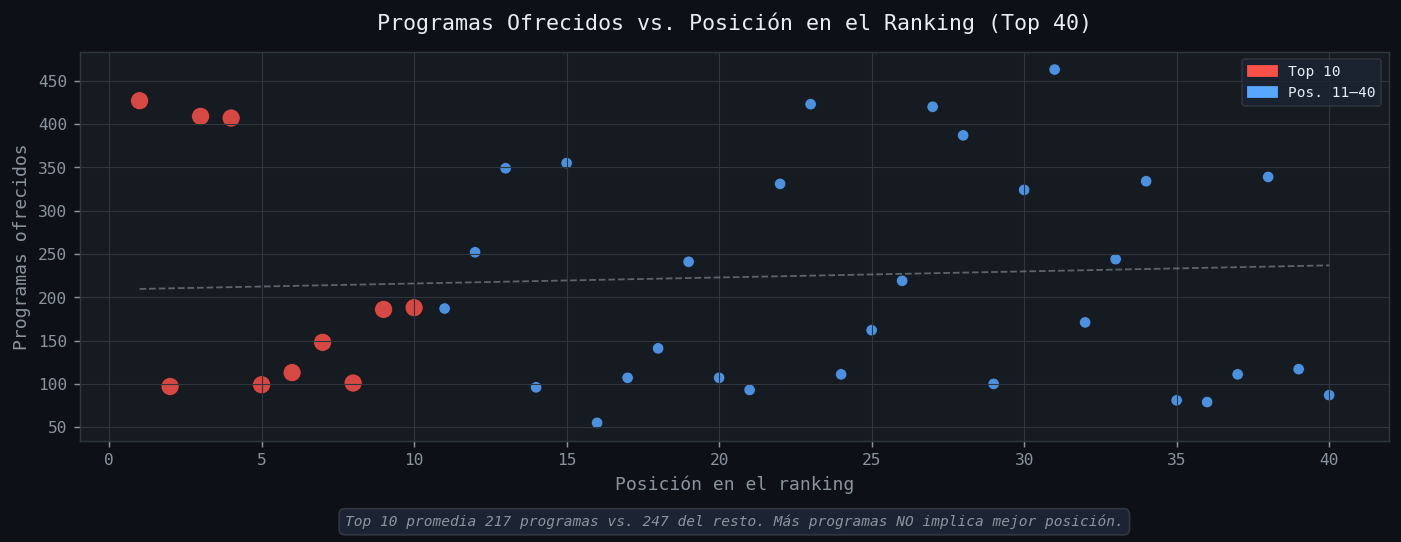

In [ ]:
# (gráfico generado por el bloque de código anterior)

---
## 📊 Gráfico 3 — Públicas vs. Privadas

**¿Qué muestra este gráfico?**  
Compara el promedio de profesores entre 4 grupos:  
públicas top10, privadas top10, públicas del resto, privadas del resto.

**Cómo leer este gráfico:**
- Barras **sólidas** (izquierda) = Top 10
- Barras **semitransparentes** (derecha) = Resto del ranking
- 🔵 azul = universidades públicas · 🟡 dorado = universidades privadas
- La línea punteada vertical separa los dos grupos

**Truco de color:** en HEX, agregar `'44'` al final de un color lo hace semitransparente (~27% de opacidad).


In [ ]:
fig3, ax3 = plt.subplots(figsize=(10, 4.5), facecolor=DARK_BG)

grupos3 = ['Públicas\nTop 10', 'Privadas\nTop 10', 'Públicas\nResto', 'Privadas\nResto']
vals3   = [3984, 3191, 4429, 4557]   # promedios de facultad por grupo

# '44' en HEX representa ~27% de opacidad → barra semitransparente
# Usamos esto para mostrar visualmente que son el grupo "de fondo"
clrs3 = [ACCENT, ACCENT2, ACCENT + '44', ACCENT2 + '44']

bars3 = ax3.bar(range(4), vals3, color=clrs3, width=0.55, edgecolor=DARK_BG, linewidth=0.6)

# Número encima de cada barra (el :, formatea con coma de miles → 3,984)
for bar, val in zip(bars3, vals3):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
             f'{val:,}', ha='center', va='bottom', fontsize=9, color=TEXT, fontweight='bold')

# Línea vertical punteada para separar visualmente los dos grupos
ax3.axvline(1.5, color=BORDER, lw=1.5, linestyle=':')
ax3.set_xticks(range(4))
ax3.set_xticklabels(grupos3, fontsize=9)
ax3.set_ylabel('Nº profesores promedio', color=MUTED)
ax3.set_title('Facultad Promedio — Públicas vs. Privadas · Top 10 vs Resto', color=TEXT)
ax3.text(0.5, -0.22,
         'Empate exacto: 5 públicas + 5 privadas en el Top 10. Ambas tienen MENOS profesores que sus pares fuera del top.',
         transform=ax3.transAxes, ha='center', fontsize=8, color=MUTED, style='italic', bbox=nota_style)

plt.tight_layout(pad=1.5)
plt.show()

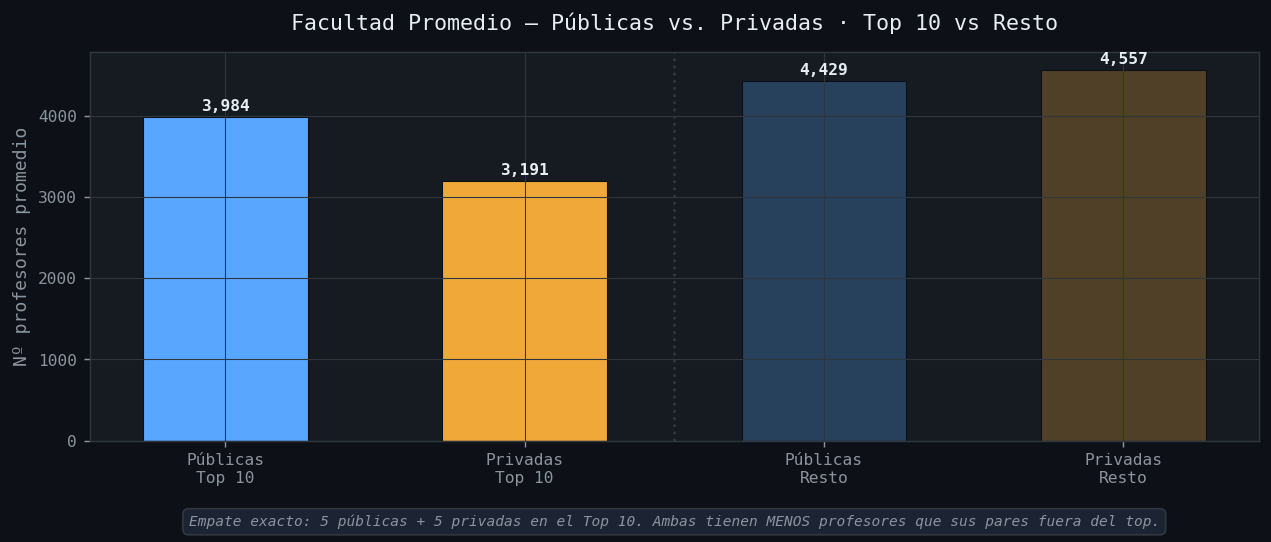

In [ ]:
# (gráfico generado por el bloque de código anterior)

---
## 📊 Gráfico 4 — Perfil Normalizado (Radar)

**¿Qué es un radar chart (spider chart)?**  
Muestra varias variables a la vez para comparar perfiles.  
Cada "pata" del radar es una variable, cada línea de color es una universidad.  
La **forma** que dibuja cada línea representa su perfil único.

**¿Por qué normalizamos?**  
Para comparar variables con escalas muy distintas:
- Facultad va de 675 a 7.242 profesores
- Programas va de 97 a 427

Si graficamos estos números directamente, la facultad dominaría visualmente.  
**Solución:** el valor máximo del grupo = 100, el resto se escala proporcionalmente.

**Nota:** "Atención Personal" está **invertida**: a menor ratio (menos alumnos por profe) = mejor atención = valor más alto en el radar.


In [ ]:
fig4, ax4 = plt.subplots(figsize=(7, 7), facecolor=DARK_BG, subplot_kw=dict(polar=True))

# polar=True crea un sistema de coordenadas circular en lugar del habitual (X,Y)
cats4 = ['Facultad', 'Programas', 'Estudiantes', 'Atención\nPersonal', 'Campus']
N     = len(cats4)

# Dividimos el círculo completo (2π radianes) en N partes iguales
# Repetimos el primer ángulo al final para cerrar el polígono
angles = [n / N * 2 * np.pi for n in range(N)]
angles += angles[:1]

# Máximos para normalizar (el valor máximo del grupo pasa a ser 100)
mxf = top10['Total_Faculty'].max()
mxp = top10['Programs_Offered'].max()
mxs = top10['Total_Students'].max()
mxr = top10['ratio'].max()
mxc = top10['Campus_Area_Acres'].max()

rcolors = [ACCENT, ACCENT2, ACCENT3, ACCENT4, '#a78bfa']
rlabels = ['#1 Oxford', '#2 Columbia', '#3 Michigan', '#4 Edinburgh', '#5 Cambridge']

# .iterrows() recorre el DataFrame fila por fila
# enumerate() nos da el índice (i) además de cada fila
for i, (_, row) in enumerate(top10.head(5).iterrows()):
    v = [
        row['Total_Faculty']     / mxf * 100,   # Facultad normalizada
        row['Programs_Offered']  / mxp * 100,   # Programas normalizados
        row['Total_Students']    / mxs * 100,   # Estudiantes normalizados
        (1 - row['ratio'] / mxr) * 100,         # Atención: INVERTIDA (menos ratio = mejor)
        row['Campus_Area_Acres'] / mxc * 100,   # Campus normalizado
    ]
    v += v[:1]   # cerramos el polígono repitiendo el primer valor

    ax4.plot(angles, v, 'o-', lw=1.5, color=rcolors[i], alpha=0.9, label=rlabels[i])
    ax4.fill(angles, v, alpha=0.07, color=rcolors[i])   # área sombreada semitransparente

ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(cats4, size=9, color=TEXT)
ax4.set_ylim(0, 100)
ax4.grid(color=BORDER, lw=0.6)
ax4.set_facecolor(SURFACE)
ax4.spines['polar'].set_color(BORDER)
ax4.set_title('Perfil Normalizado (0–100) — Top 5 Universidades\nCada eje = variable normalizada respecto al máximo del grupo',
              color=TEXT, pad=18)
ax4.legend(loc='upper right', bbox_to_anchor=(1.38, 1.12))

plt.tight_layout(pad=1.5)
plt.show()

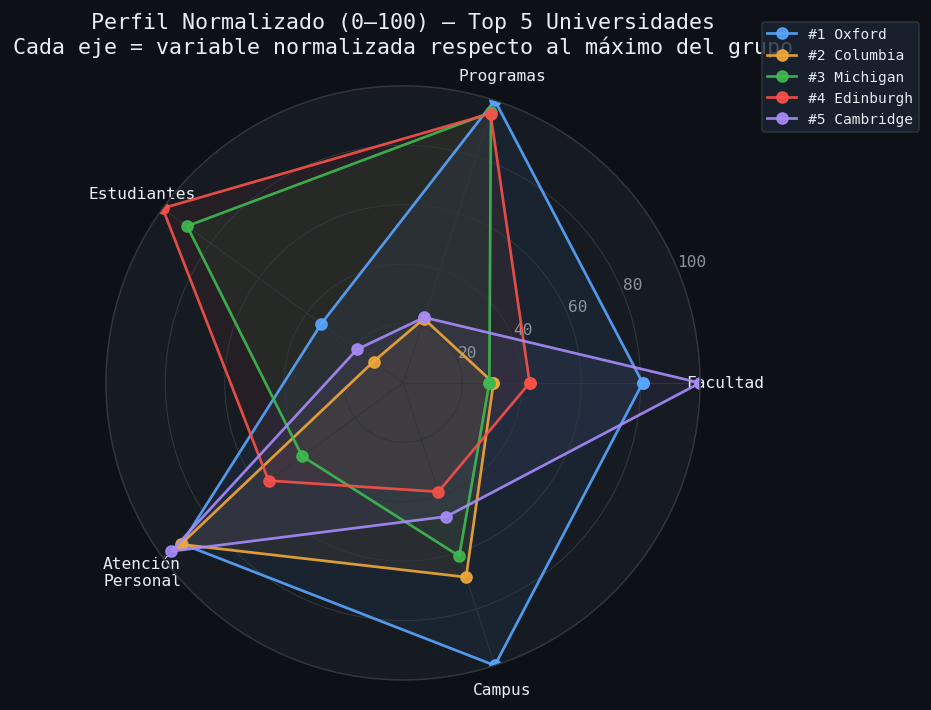

In [ ]:
# (gráfico generado por el bloque de código anterior)

---
## 📊 Gráfico 5 — Histograma de Distribución

**¿Qué es un histograma?**  
Agrupa los datos en rangos ("bins") y muestra cuántas universidades caen en cada rango.  
Es ideal para ver si los datos están concentrados, dispersos o tienen valores extremos.

**Cómo leer este gráfico:**
- El eje X muestra el número de profesores
- El eje Y muestra cuántas universidades tienen ese número
- 🔵 histograma azul claro = posiciones 11–100
- 🔴 histograma rojo = Top 10 (superpuesto)
- Las líneas punteadas = promedio de cada grupo

**Qué buscamos:** si las Top 10 se concentran en la parte derecha del gráfico (muchos profesores), confirmaría que más recursos = mejor ranking. Si no lo hacen... no hay relación.


In [ ]:
fig5, ax5 = plt.subplots(figsize=(11, 4.5), facecolor=DARK_BG)

# Graficamos dos histogramas superpuestos con diferentes colores y transparencia
# bins=18 divide el rango de valores en 18 intervalos iguales
# Los colores con '88' o 'cc' al final son versiones semitransparentes en HEX
ax5.hist(rest['Total_Faculty'],  bins=18, color=ACCENT + '88',
         edgecolor=DARK_BG, lw=0.4, label='Posiciones 11–100')
ax5.hist(top10['Total_Faculty'], bins=7,  color=ACCENT4 + 'cc',
         edgecolor=DARK_BG, lw=0.4, label='Top 10')

# axvline dibuja una línea vertical en el promedio de cada grupo
# Permite comparar visualmente dónde está concentrada cada distribución
ax5.axvline(top10['Total_Faculty'].mean(), color=ACCENT4, lw=1.5, linestyle='--',
            label=f'Media Top 10: {top10["Total_Faculty"].mean():.0f}')
ax5.axvline(rest['Total_Faculty'].mean(),  color=ACCENT,  lw=1.5, linestyle='--',
            label=f'Media Resto : {rest["Total_Faculty"].mean():.0f}')

ax5.set_title('Distribución del Nº de Profesores — Top 10 vs. Resto', color=TEXT)
ax5.set_xlabel('Total de profesores', color=MUTED)
ax5.set_ylabel('Frecuencia (universidades)', color=MUTED)
ax5.legend()
ax5.text(0.5, -0.22,
         'Las Top 10 no se concentran en valores altos de facultad. Se dispersan por todo el rango, igual que el resto.',
         transform=ax5.transAxes, ha='center', fontsize=8, color=MUTED, style='italic', bbox=nota_style)

plt.tight_layout(pad=1.5)
plt.show()

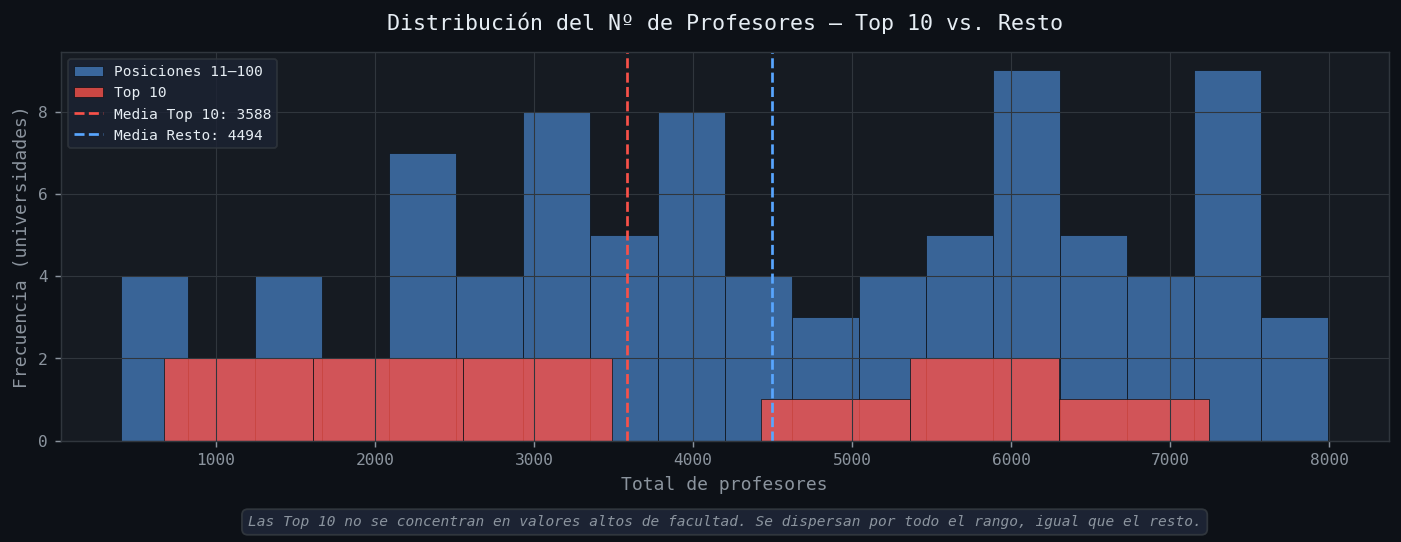

In [ ]:
# (gráfico generado por el bloque de código anterior)

---
## 📊 Gráfico 6 — Heatmap de Correlaciones

**¿Qué es un heatmap (mapa de calor)?**  
Una tabla donde el **color** de cada celda indica el valor que contiene.  
Acá mostramos la **matriz de correlación**: qué tan relacionada está cada variable con las demás.

**Cómo leer este gráfico:**
- 🔵 Azul fuerte = correlación positiva alta (cerca de +1)
- 🔴 Rojo fuerte = correlación negativa alta (cerca de −1)
- ⚪ Blanco/gris = sin correlación (cerca de 0)
- La diagonal siempre es 1 (cada variable se correlaciona perfectamente consigo misma)

**Lo más importante:** mirar la **primera fila/columna "Posición"**.  
Si todos sus valores están cerca de 0 → ninguna variable predice el ranking.


In [ ]:
fig6, ax6 = plt.subplots(figsize=(7, 6), facecolor=DARK_BG)

# Seleccionamos las columnas numéricas relevantes y las renombramos al español
vcols = df[['Position','Total_Faculty','Programs_Offered',
            'ratio','Total_Students','Campus_Area_Acres']].copy()
vcols.columns = ['Posición','Facultad','Programas','Ratio','Estudiantes','Campus']

# .corr() calcula la correlación entre todas las columnas
# El resultado es una tabla NxN: celda (i,j) = correlación entre variable i y variable j
# sns.diverging_palette genera una paleta que va de azul a rojo pasando por blanco en 0
cmap6 = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(vcols.corr(),
            ax=ax6,
            annot=True,      # muestra el número dentro de cada celda
            fmt='.2f',       # formato con 2 decimales
            cmap=cmap6,      # paleta azul-rojo
            center=0,        # el color neutro (blanco) corresponde al valor 0
            vmin=-1, vmax=1, # la escala siempre va de -1 a 1 (no se ajusta a los datos)
            annot_kws={'size': 9, 'color': TEXT},
            linewidths=0.5,
            linecolor=DARK_BG,
            cbar_kws={'shrink': 0.75})

ax6.set_title('Mapa de Correlaciones entre Variables\nFila "Posición" ≈ 0 en todo → ninguna variable predice el ranking',
              color=TEXT)
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax6.set_yticklabels(ax6.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout(pad=1.5)
plt.show()

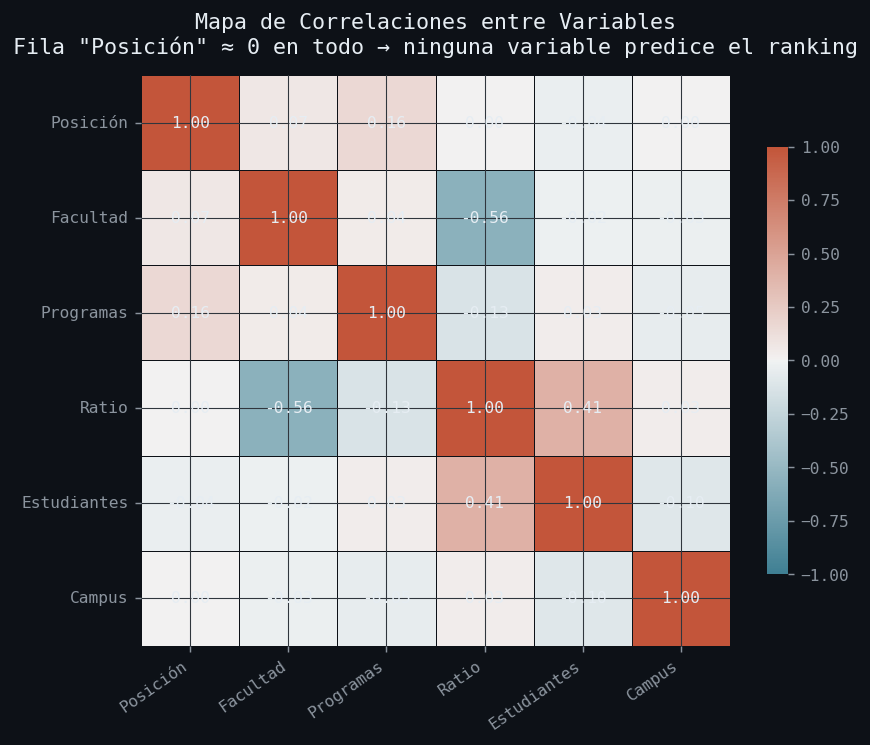

In [ ]:
# (gráfico generado por el bloque de código anterior)

---
## ✅ Conclusiones Finales

Después de analizar las 4 preguntas con 6 gráficos distintos, la respuesta más honesta es:  
**los recursos cuantificables no explican por qué estas universidades son las mejores del mundo.**

---

### Q1 — Ratio estudiante/profesor
- Correlación con el ranking: **0.001 ≈ cero**
- Rango dentro del Top 10: desde **1.53** (Cambridge) hasta **42.52** (UCL)
- **Conclusión:** no es un factor diferenciador. Hay Top 10 con atención muy personalizada y otras masivas.

### Q2 — Programas ofrecidos
- Top 10 promedia **217 programas** vs. **247** del resto
- Correlación: **0.158** (débil)
- **Conclusión:** las mejores universidades tienen *menos* programas en promedio. Calidad > cantidad.

### Q3 — Tipo de institución
- Empate exacto: **5 públicas y 5 privadas** en el Top 10
- Ambas tienen menos facultad que sus pares fuera del top
- **Conclusión:** el tipo de financiamiento no determina el ranking.

### Q4 — Perfil típico
- Correlación facultad–ranking: **0.067**
- Los perfiles radar son completamente distintos entre sí
- **Conclusión:** no existe un "molde". El ranking refleja algo que estas variables no miden: **reputación histórica, producción científica e impacto global**.

---

> 💡 **Próximo paso sugerido:** incorporar datos de publicaciones científicas, citas académicas o rankings de reputación para encontrar los verdaderos predictores del ranking.
